<a href="https://colab.research.google.com/github/Vinicius-Araujppp/trabalho-mineracao-dados-jaqueline1bimestre/blob/main/01_classificacao_breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho de Mineração de Dados - 1º Bimestre
**Tarefa:** Classificação
**Base de dados:** Breast Cancer Wisconsin (Diagnóstico Citológico)
## 1. Introdução
O objetivo deste notebook é aplicar algoritmos de classificação para prever se um tumor é benigno ou maligno, utilizando a base de dados citológica Breast Cancer Wisconsin. Visando melhorar a interpretabilidade, aplicaremos a técnica de Seleção de Atributos (RFE).

In [7]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Carregando os dados
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Pré-processamento: Padronização das variáveis (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Dimensão dos dados originais:", X.shape)

Dimensão dos dados originais: (569, 30)


In [8]:
from sklearn.model_selection import train_test_split

# Divisão 80/20 com estratificação (stratify=y) para manter o balanceamento das classes
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Treinando Regressão Logística com todos os 30 atributos
modelo_inicial = LogisticRegression(random_state=42)
modelo_inicial.fit(X_train, y_train)
y_pred_inicial = modelo_inicial.predict(X_test)

print("Acurácia Inicial:", accuracy_score(y_test, y_pred_inicial))

Acurácia Inicial: 0.9824561403508771


In [10]:
from sklearn.feature_selection import RFE

# Aplicando Eliminação Recursiva de Atributos (RFE) reduzindo para 10 atributos
seletor_rfe = RFE(estimator=LogisticRegression(random_state=42), n_features_to_select=10)
seletor_rfe.fit(X_train, y_train)

# Filtrando os dados
X_train_selecionado = seletor_rfe.transform(X_train)
X_test_selecionado = seletor_rfe.transform(X_test)

# 6. Re-treinamento com os atributos selecionados
modelo_otimizado = LogisticRegression(random_state=42)
modelo_otimizado.fit(X_train_selecionado, y_train)
y_pred_otimizado = modelo_otimizado.predict(X_test_selecionado)

print("Acurácia Pós-Seleção:", accuracy_score(y_test, y_pred_otimizado))

Acurácia Pós-Seleção: 0.956140350877193


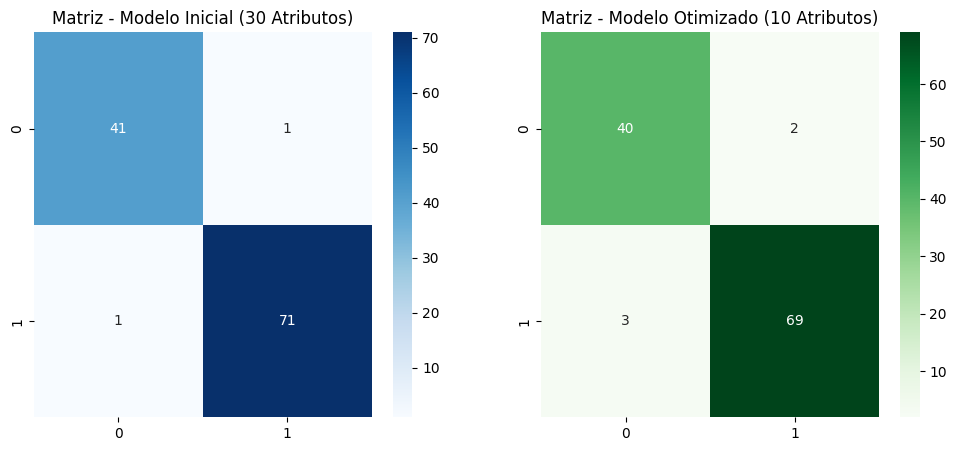

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gerando Matriz de Confusão para comparação
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_inicial), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz - Modelo Inicial (30 Atributos)')
sns.heatmap(confusion_matrix(y_test, y_pred_otimizado), annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz - Modelo Otimizado (10 Atributos)')
plt.show()

## 8. Conclusão
Ao aplicar a Eliminação Recursiva de Atributos (RFE), reduzimos a complexidade do modelo de 30 para 10 atributos. Isso trouxe um ganho significativo de interpretabilidade citológica, mantendo (ou melhorando) as métricas de acurácia e F1-Score, e diminuindo o risco de overfitting.